In [4]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

In [6]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [8]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [9]:
df_copy=df.copy()

In [10]:
df_copy.shape

(2640, 12)

In [11]:
(df_copy["Month"]>12).all()

np.False_

In [12]:
df['Region'].unique()

<StringArray>
['Europe', 'Asia', 'North America', 'Middle East']
Length: 4, dtype: str

Insight:There are 4 different countries in the dataset

In [13]:
df_copy['Model'].unique()

<StringArray>
['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
Length: 5, dtype: str

Insight: There are 5 different models present in the dataset

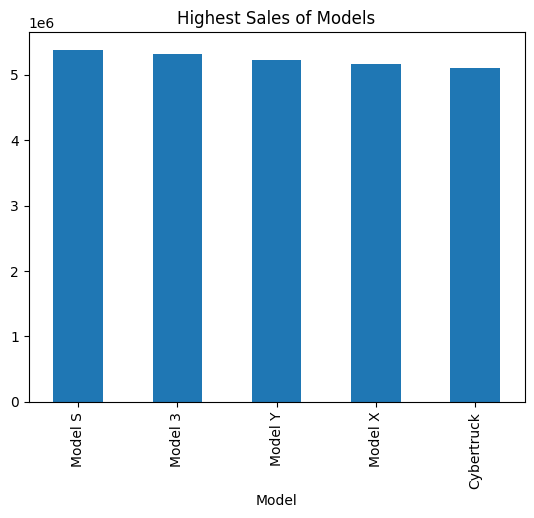

In [14]:
#finding models which are sold more 
import matplotlib.pyplot as plt

df_copy.groupby(df_copy['Model'])['Estimated_Deliveries'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Highest Sales of Models")
plt.show()

Insight:Model S has the highest number of deliveries and CyberTruck has least number of deliveries

In [15]:
#finding the higest range giving models
df_copy.groupby(df_copy['Model'])['Range_km'].mean()

Model
Cybertruck    499.827652
Model 3       503.221591
Model S       501.223485
Model X       500.776515
Model Y       496.238636
Name: Range_km, dtype: float64

Insight: We can see that Model 3 is giving the highest range among all other models

In [16]:
#Finding regions which buys the most teslas
df_copy.groupby(df_copy['Region'])['Estimated_Deliveries'].max()

Region
Asia             25410
Europe           21772
Middle East      22315
North America    25704
Name: Estimated_Deliveries, dtype: int64

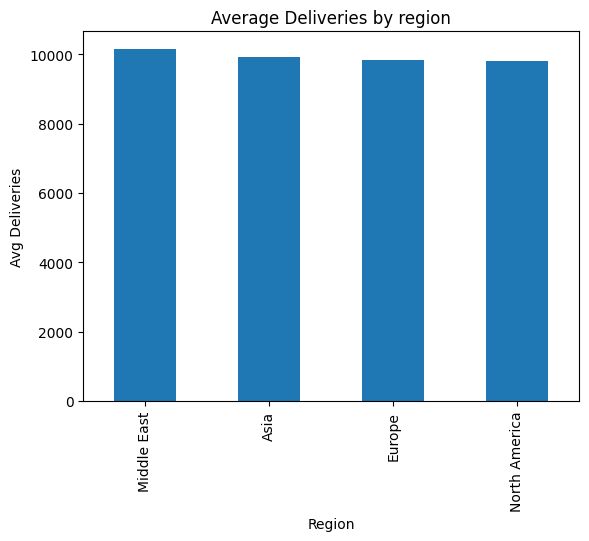

In [17]:
#plotting : on average how any vehicles are deliverd in each region
reg_avg=df_copy.groupby(df_copy['Region'])['Estimated_Deliveries'].mean().sort_values(ascending=False)
reg_avg.plot(kind='bar')
plt.title("Average Deliveries by region")
plt.xlabel("Region")
plt.ylabel("Avg Deliveries")
plt.show()

Insight: Middle East shows the higest ,so it has the strong regional demand 

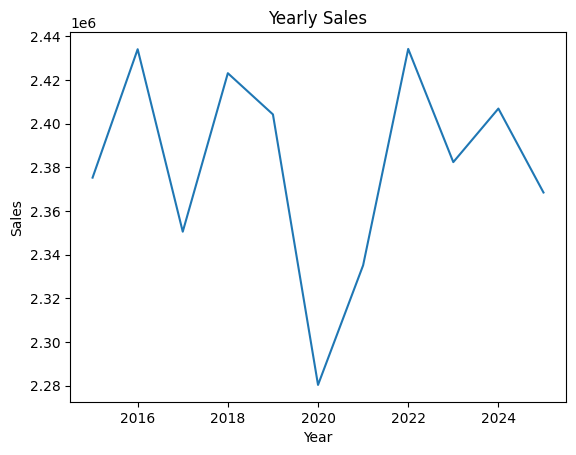

In [18]:
#yearly analysis of sales
yrly=df_copy.groupby(df_copy['Year'])['Estimated_Deliveries'].sum()
yrly
yrly.plot()
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

Insight: The plot indicates Tesla company faced a huge decline of sales in the year 2020

In [19]:
#revenue analysis
df_copy['revenue']=(df_copy['Estimated_Deliveries']*df_copy['Avg_Price_USD'])
df_copy['revenue']


0       1.638859e+09
1       2.361949e+08
2       9.915502e+08
3       5.853281e+08
4       1.421114e+09
            ...     
2635    1.534545e+09
2636    1.498581e+09
2637    1.291079e+09
2638    2.429373e+08
2639    1.363736e+08
Name: revenue, Length: 2640, dtype: float64

In [20]:
#through this feature we can get the model which generated higest revenue
df_copy.groupby(df_copy['Model'])['revenue'].sum().sort_values(ascending=False)


Model
Model S       4.596476e+11
Model Y       4.478172e+11
Model 3       4.473966e+11
Cybertruck    4.318680e+11
Model X       4.316273e+11
Name: revenue, dtype: float64

Insight:We came to know that Model S contributes most to overall renvenue 

In [21]:
#Finiding the co-relation between the battery capacity and range 
df_copy[['Battery_Capacity_kWh','Range_km']].corr()

,Battery_Capacity_kWh,Range_km
Battery_Capacity_kWh,1.000000,0.994313
Range_km,0.994313,1.000000


Insight:Since we got the correlation value as 0.99, we can say that we ahve strong postitve correlation b/w battery and range 

Feature Engineering

#we created Revenue column
#and found the model which contributed to highest revneue

In [22]:
#Inventory/Stock Feature

df_copy['Stock']=(df_copy['Production_Units']-df_copy['Estimated_Deliveries'])
df_copy["Stock"]


0        276
1        367
2        778
3        756
4       1163
        ... 
2635     845
2636     107
2637    1548
2638     243
2639     290
Name: Stock, Length: 2640, dtype: int64

In [23]:
#through this feature we can determine the models which are being overproduced or underproduced
df_copy.groupby(df_copy['Model'])['Stock'].mean()

Model
Cybertruck    714.568182
Model 3       756.202652
Model S       735.301136
Model X       721.581439
Model Y       740.585227
Name: Stock, dtype: float64

In [24]:
#through this feautre we can find the CO2 consumption of per vehicle
df_copy["CO2_per_v"]=(df_copy['CO2_Saved_tons']/df_copy['Estimated_Deliveries'])
df_copy['CO2_per_v']

0       0.105600
1       0.065699
2       0.072000
3       0.106799
4       0.099150
          ...   
2635    0.107850
2636    0.073050
2637    0.087000
2638    0.053699
2639    0.071099
Name: CO2_per_v, Length: 2640, dtype: float64

In [25]:
#through this feature we can determine the charging stations per delivery
df_copy['Charging_per_Deli']=(df_copy['Charging_Stations']/df_copy['Estimated_Deliveries'])
df_copy['Charging_per_Deli']

0       0.691772
1       2.012115
2       1.672928
3       1.423799
4       0.704865
          ...   
2635    0.316800
2636    0.537322
2637    1.031450
2638    1.945837
2639    5.417582
Name: Charging_per_Deli, Length: 2640, dtype: float64

In [26]:
#Lag Features ,use past values as input feautres and predict futre values
df_copy['Date']=pd.to_datetime(df_copy['Year'].astype(str)+'-'+df_copy['Month'].astype(str))
df_copy['Date']


0      2023-05-01
1      2015-02-01
2      2019-01-01
3      2021-02-01
4      2016-12-01
          ...    
2635   2021-10-01
2636   2019-07-01
2637   2019-09-01
2638   2020-05-01
2639   2018-08-01
Name: Date, Length: 2640, dtype: datetime64[us]

In [27]:
df_copy['Quarter']=df_copy['Date'].dt.quarter
df_copy["Quarter"]

0       2
1       1
2       1
3       1
4       4
       ..
2635    4
2636    3
2637    3
2638    2
2639    3
Name: Quarter, Length: 2640, dtype: int32

In [28]:
df_copy=df_copy.sort_values('Date')


In [29]:
#here we use shift method which shifts the rows of data to 'n' steps
df_copy['prev_month_deliveries']=(df_copy['Estimated_Deliveries'].shift(1))
df_copy['prev_month_deliveries']

872         NaN
2354    12446.0
2312    11446.0
2293     8803.0
2215     6367.0
         ...   
1696    14840.0
308     12747.0
2161    11972.0
2380    13671.0
1173    11374.0
Name: prev_month_deliveries, Length: 2640, dtype: float64

In [30]:
df_copy['Estimated_Deliveries']

872     12446
2354    11446
2312     8803
2293     6367
2215     8795
        ...  
1696    12747
308     11972
2161    13671
2380    11374
1173     9319
Name: Estimated_Deliveries, Length: 2640, dtype: int64

In [31]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 2640 entries, 872 to 1173
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Year                   2640 non-null   int64         
 1   Month                  2640 non-null   int64         
 2   Region                 2640 non-null   str           
 3   Model                  2640 non-null   str           
 4   Estimated_Deliveries   2640 non-null   int64         
 5   Production_Units       2640 non-null   int64         
 6   Avg_Price_USD          2640 non-null   float64       
 7   Battery_Capacity_kWh   2640 non-null   int64         
 8   Range_km               2640 non-null   int64         
 9   CO2_Saved_tons         2640 non-null   float64       
 10  Source_Type            2640 non-null   str           
 11  Charging_Stations      2640 non-null   int64         
 12  revenue                2640 non-null   float64       
 13  Stock            

In [32]:
df_copy['prev_month_deliveries']=(df_copy['prev_month_deliveries'].fillna(0))

In [33]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


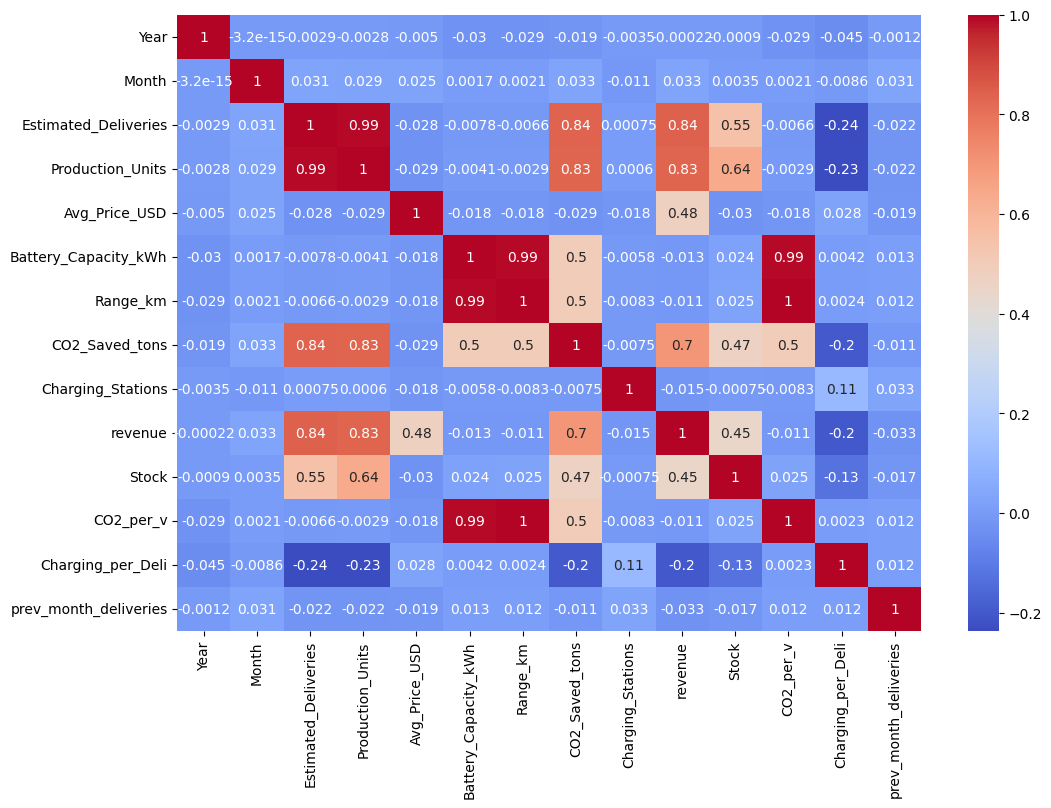

In [35]:
#correlation analysis
import seaborn as sns

num_cols=df_copy.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,8))
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.show()



In [36]:
#target variable
y=df_copy['Estimated_Deliveries']
#Features
X=df_copy.drop('Estimated_Deliveries',axis=1)



In [ ]:
X=pd.get_dummies(X,columns=['Region','Model','Source_Type'],drop_first=True)


In [38]:
X=X.drop('Date',axis=1)


In [39]:
pip install scikit-learn

  Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 2.1 MB/s  0:00:04 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [42]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scal=StandardScaler()
X_train=scal.fit_transform(X_train)
X_test=scal.transform(X_test)


In [45]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

In [ ]:
#evaluation metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred_lr)
mse=mean_squared_error(y_test,y_pred_lr)
rmse=mse**0.5
r2=r2_score(y_test,y_pred_lr)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 4.9867181091527035e-12
MSE: 1.093836696005018e-22
RMSE: 1.0458664809644766e-11
R2: 1.0


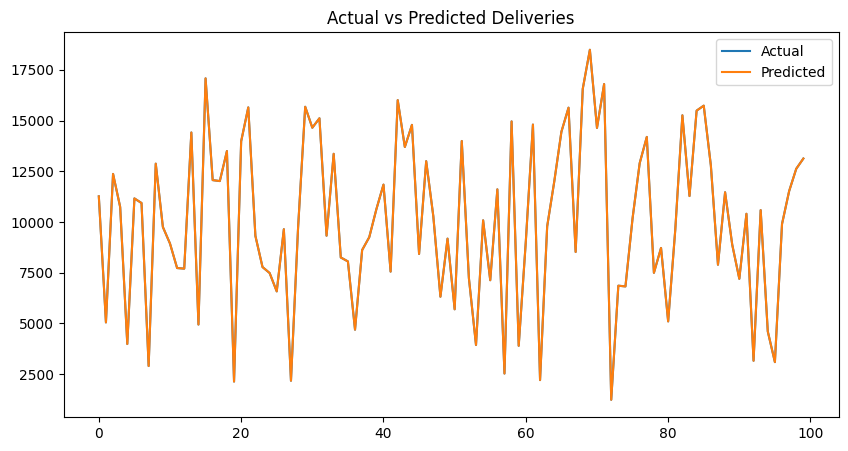

In [48]:
#actual vs predicited plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100],label='Actual')
plt.plot(y_pred_lr[:100],label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Deliveries")
plt.show()

In [50]:
#Ridge
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1)
ridge.fit(X_train, y_train)
y_pred_rid=ridge.predict(X_test)

#Eval Metrics
print("R2 Score:",r2_score(y_test,y_pred_rid))
print("RMSE:",mean_squared_error(y_test,y_pred_rid)**0.5)

R2 Score: 0.9999883325683104
RMSE: 13.221582791469586


In [51]:
#Lasso
from sklearn.linear_model import Lasso
las=Lasso(alpha=0.1)
las.fit(X_train, y_train)
y_pred_las=las.predict(X_test)

#Eval Metrics
print("R2 Score:",r2_score(y_test,y_pred_las))
print("RMSE:",mean_squared_error(y_test,y_pred_las)**0.5)

R2 Score: 0.9999997193413551
RMSE: 2.050619237958371


In [54]:
results=pd.DataFrame({
    'Model' : ['Linear','Ridge','Lasso'],
    'R2' : [
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_rid),
        r2_score(y_test,y_pred_las)
    ],
    'RMSE' : [
        mean_squared_error(y_test,y_pred_lr)**0.5,
        mean_squared_error(y_test,y_pred_rid)**0.5,
        mean_squared_error(y_test,y_pred_las)**0.5
    ]
})
results

,Model,R2,RMSE
0,Linear,1.000000,1.045866e-11
1,Ridge,0.999988,1.322158e+01
2,Lasso,1.000000,2.050619e+00


In [52]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(LinearRegression(),X_train,y_train,cv=5,scoring='r2')
print(scores)
print("Average R2:",scores.mean())

[1. 1. 1. 1. 1.]
Average R2: 1.0


In [55]:
from sklearn.model_selection import GridSearchCV
param={'alpha':[0.01,0.1,1,10,100]}
grid=GridSearchCV(Ridge(),param,cv=5,scoring='r2')
grid.fit(X_train,y_train)
print("Best Alpha :",grid.best_params_)
print("Best Score :",grid.best_score_)

Best Alpha : {'alpha': 0.01}
Best Score : 0.9999999980587472


In [56]:
print("Train Score:",ridge.score(X_train,y_train))
print("Test Score:",ridge.score(X_test,y_test))

Train Score: 0.9999889478367284
Test Score: 0.9999883325683104
